In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/air_quality_prediction/train_data.csv')
test_df = pd.read_csv('/content/drive/MyDrive/air_quality_prediction/test_data.csv')

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [34]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date')
df = df.ffill()

In [35]:
# Rolling feature
df['pm2_5_avg_3'] = df['pm2_5'].rolling(window=3).mean()

# Time features
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month

# Encode location
df['location'] = df['location'].astype('category').cat.codes

df = df.dropna()

In [36]:
features = [
    'pm2_5',
    'pm10',
    'temperature',
    'pm2_5_avg_3',
    'location',
    'day',
    'month'
]

target = 'predicted_aqi'

X = df[features]
y = df[target]

In [37]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [38]:
def create_sequences(X, y, time_steps=3):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 3
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)


In [39]:
split = int(0.8 * len(X_seq))

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

In [40]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(25))
model.add(Dense(10, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 3, 50)          │        11,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,471 (76.06 KB)

 Trainable params: 19,471 (76.06 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test))

Epoch 1/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0350 - val_loss: 0.0260
Epoch 2/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0247 - val_loss: 0.0233
Epoch 3/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0237 - val_loss: 0.0227
Epoch 4/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0230 - val_loss: 0.0225
Epoch 5/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0234 - val_loss: 0.0225
Epoch 6/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0229 - val_loss: 0.0226
Epoch 7/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0228 - val_loss: 0.0225
Epoch 8/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0226 - val_loss: 0.0224
Epoch 9/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0226 - val_loss: 0.0224
Epoch 10/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0229 - val_loss: 0.0233
Epoch 11/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0228 - val_loss: 0.0224
Epoch 12/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/ste

In [44]:
y_pred = model.predict(X_test)

y_test_actual = scaler_y.inverse_transform(y_test)
y_pred_actual = scaler_y.inverse_transform(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)

print("RMSE:", rmse)
print("MAE:", mae)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
RMSE: 9.763266764332437
MAE: 7.879442653590458


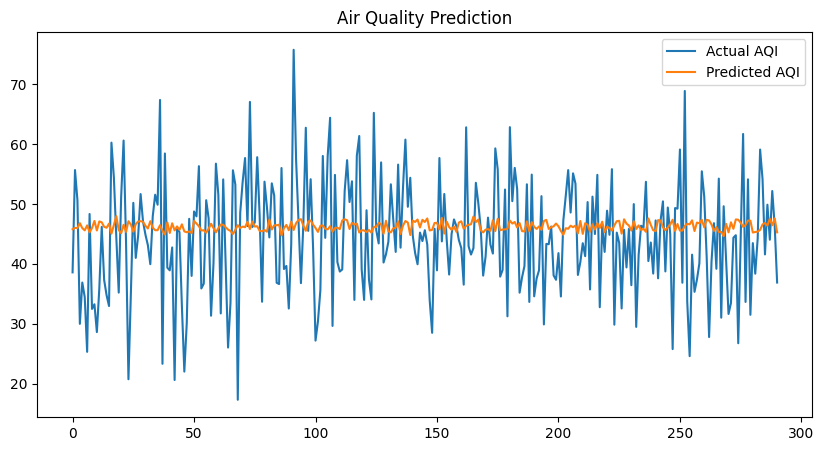

In [45]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual AQI")
plt.plot(y_pred_actual, label="Predicted AQI")
plt.legend()
plt.title("Air Quality Prediction")
plt.show()

In [46]:
test_df['date'] = pd.to_datetime(test_df['date'], dayfirst=True)
test_df = test_df.ffill()

In [47]:
test_df['pm2_5_avg_3'] = test_df['pm2_5'].rolling(window=3).mean()
test_df['day'] = test_df['date'].dt.day
test_df['month'] = test_df['date'].dt.month

# Add missing features
test_df['location'] = 0
test_df['pm10'] = test_df['pm2_5'] * 1.5

test_df = test_df.dropna()